# Project. Startup Research

## Step 1. Getting to Know the Data: Loading and Preprocessing

The dataset was obtained from a startup database.

The main dataset is named `cb_investments.zip`. The archive contains one file, `cb_investments.csv`.

Data Description:
* `name` — The company name.
* `homepage_url` — A link to the company's website.
* `category_list` — The categories the company operates in. Separated by `|`.
* `market` — The company's primary market or industry.
* `funding_total_usd` — The total amount of investments raised in US dollars.
* `status` — The company's current status, such as `operating`, `closed`, and so on.
* `country_code` — The country code, such as USA.
* `state_code` — The state or region code, such as CA.
* `region` — The region, such as the SF Bay Area.
* `city` — The city where the company is located.
* `funding_rounds` — The total number of funding rounds.
* `participants` — The number of participants in funding rounds.
* `founded_at` — The company's founding date.
* `founded_month` — the month of foundation in `YYYY-MM` format.
* `founded_quarter` — the quarter of foundation in `YYYY-QN` format.
* `founded_year` — the year of foundation.
* `first_funding_at` — the date of the first funding round.
* `mid_funding_at` — the date of the mid-term funding round.
* `last_funding_at` — the date of the last funding round.
* `seed` — the amount of investment at the seed stage.
* `venture` — the amount of venture investments.
* `equity_crowdfunding` — the amount raised through equity crowdfunding.
* `undisclosed` — the amount of funding of an undisclosed type.
* `convertible_note` — the amount of investment through convertible notes.
* `debt_financing` — the amount of debt financing.
* `angel` — the amount of investments from business angels.
* `grant` — the amount of grants received.
* `private_equity` — the amount of investments in the form of direct (private) investments.
* `post_ipo_equity` — the amount of financing after the IPO.
* `post_ipo_debt` — the amount of debt financing after the IPO.
* `secondary_market` — the amount of transactions on the secondary market.
* `product_crowdfunding` — the amount raised through product crowdfunding.
* `round_A` — `round_H` — the amount of investments in the corresponding round.


The name of the additional dataset is `cb_returns.csv`. It contains return amounts by financing type in millions of dollars by year.

Data Description:
* `year` — Year of repayment.
* `seed` — Amount of returns from seed investments.
* `venture` — Amount of returns from venture investments.
* `equity_crowdfunding` — Amount returned from equity crowdfunding.
* `undisclosed` — Amount of returns of an undisclosed type.
* `convertible_note` — Amount of returns through convertible notes.
* `debt_financing` — Amount of returns from debt financing.
* `angel` — Amount of returns to business angels.
* `grant` — Amount of returns from grants.
* `private_equity` — Amount of returns from direct (private) investments.
* `post_ipo_equity` — Amount of returns from IPO.
* `post_ipo_debt` — Amount of returns from a debt IPO. * `secondary_market` — the amount of returns from secondary market transactions.
* `product_crowdfunding` — the amount of returns from product crowdfunding.


The files are located in the `datasets` folder if you're working on the platform. If you're working locally, you can access the files in the folder at `https://code.s3.yandex.net/datasets/` + the file name.

### 1.1. Displaying general information



In [68]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np


`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [69]:
investments_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [70]:
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [71]:
returns_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [72]:
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [73]:
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [74]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


The cb_investments.csv dataset contains 40 columns and 54,294 rows, containing information about companies and completed financings. All columns in the cb_investments.csv dataset contain gaps. The largest number of gaps is in the state_code and mid_funding_at columns.
The cb_returns.csv dataset contains 14 columns and 15 rows, containing information about return amounts by year and financing type in millions of dollars.

There are no gaps in the cb_returns.csv dataset.
In the cb_investments.csv dataset, the market and funding_total_usd column names contain spaces before the column names, and the round_A through round_H columns do not conform to the snake_case style. The round names must be converted to lowercase.
The column values in both datasets match their descriptions.
The date column values in the cb_investments.csv dataset are represented in object format, not datetime64.

### 1.2. Data preprocessing

In [75]:
# Remove spaces in column names and convert to lowercase

investments_df.columns = investments_df.columns.str.strip().str.lower()

investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [76]:
investments_df['funding_total_usd'] = (
    investments_df['funding_total_usd']
    .str.replace(',', '', regex=False)  
    .str.replace('-', '', regex=False)  
    .str.strip() # Удаление пробелов
    .replace('', np.nan)  # Замена пустых строк на NaN
)
investments_df['funding_total_usd'] = pd.to_numeric(investments_df['funding_total_usd'], errors='coerce')
investments_df['funding_total_usd']

0        90000000.0
1         2000000.0
2         9000000.0
3         7700000.0
4          540000.0
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: float64

In [77]:
investments_df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']] = (investments_df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].apply(pd.to_datetime, errors='coerce'))

In [78]:
investments_df['founded_month'] = pd.to_datetime(investments_df['founded_month'])

# Преобразуем формат даты в YYYY-MM
investments_df['founded_month'] = investments_df['founded_month'].dt.strftime('%Y-%m')

investments_df['founded_quarter'] = pd.to_datetime(investments_df['founded_quarter'], format='%Y-%q', errors='coerce')

# Преобразуем формат даты в YYYY-QN
investments_df['founded_quarter'] = investments_df['founded_quarter'].dt.strftime('%Y-%q')

investments_df['founded_year'] = pd.to_datetime(investments_df['founded_year'], format='%Y', errors='coerce')

In [79]:
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [80]:
returns_df.set_index('year', inplace=True)

In [81]:
# Let's find the absolute and relative number of missing values ​​in the investments_df dataset.

investments_df.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
market                   8817
funding_total_usd       13387
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15741
founded_month           15812
founded_quarter         54294
founded_year            15741
first_funding_at         4866
mid_funding_at          24006
last_funding_at          4862
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_a                  4856
round_b   

In [82]:
(investments_df.isna().sum() / investments_df.shape[0])*100

name                      8.945740
homepage_url             15.296350
category_list            16.239363
market                   16.239363
funding_total_usd        24.656500
status                   11.364055
country_code             18.655837
state_code               44.448742
region                   18.655837
city                     20.208494
funding_rounds            8.943898
participants             43.874093
founded_at               28.992154
founded_month            29.122923
founded_quarter         100.000000
founded_year             28.992154
first_funding_at          8.962316
mid_funding_at           44.214830
last_funding_at           8.954949
seed                      8.943898
venture                   8.943898
equity_crowdfunding       8.943898
undisclosed               8.943898
convertible_note          8.943898
debt_financing            8.943898
angel                     8.943898
grant                     8.943898
private_equity            8.943898
post_ipo_equity     

In [83]:
investments_df[['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']] = investments_df[['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']].fillna('unknow')

In [84]:
# Remove extra spaces around the edges

investments_df['market'] = investments_df['market'].str.strip()

In [85]:
investments_df.duplicated().sum()

4855

In [86]:
investments_df_clean = investments_df.drop_duplicates()

In [87]:
investments_df_clean = investments_df_clean.dropna(subset=['funding_total_usd'])

Fill in the gaps in the `mid_funding_at` values ​​based on the values ​​in the `first_funding_at` and `last_funding_at` columns. Replace the gaps with the midpoint of the interval between these two dates.

Estimate the size of the remaining gaps in the column.

In [88]:
na_count = investments_df_clean['mid_funding_at'].isna().sum()

# Function to calculate the midpoint of an interval between dates
def mid_date(row):
    if pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        return row['first_funding_at'] + ((row['last_funding_at'] - row['first_funding_at']) / 2)
    return pd.NA

mask = investments_df_clean['mid_funding_at'].isna()
investments_df_clean.loc[mask, 'mid_funding_at'] = investments_df_clean[mask].apply(mid_date, axis=1)

na_count_new = investments_df_clean['mid_funding_at'].isna().sum()

display(f"Number of initial passes in mid_funding_at: {na_count}")
display(f"Number of remaining passes in mid_funding_at: {na_count_new}")



'Number of initial passes in mid_funding_at: 13676'

'Number of remaining passes in mid_funding_at: 1'

In [90]:
missed_values = investments_df_clean.isna().sum().sum()
display(f"Total number of gaps in the data: {missed_values}")

'Total number of gaps in the data: 80672'

In [91]:
investments_df_clean.isna().sum()

name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            13576
founded_at               8707
founded_month            8772
founded_quarter         40907
founded_year             8707
first_funding_at            2
mid_funding_at              1
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a                     0
round_b   

In [92]:
a, b = len(investments_df), len(investments_df_clean)
print(" There were rows in the original dataset", a,
      '\n', "Number of rows remaining in the dataset after processing", b,
      '\n', "Rows removed from the dataset after processing", a-b,
      '\n', "Loss percentage", round((a-b)/a*100, 2))

 There were rows in the original dataset 54294 
 Number of rows remaining in the dataset after processing 40907 
 Rows removed from the dataset after processing 13387 
 Loss percentage 24.66


In the investments_df_clean dataset, 80,672 missing values remained after preprocessing. During preprocessing, a large number of 13,387 rows, or 24.66%, were removed based on duplicates and missing values in the funding_total_usd column.

In [93]:
investments_df = investments_df_clean.copy()

## Шаг 2. Feature engineering

### 2.1. Groups by funding terms

We'll divide all companies into three groups:

* Single funding — there was only one funding round.

* Financing period up to a year — no more than a year passed between the first and last funding rounds.

* Financing period longer than a year.

We'll visualize the relationship between these groups by creating two graphs:

* By number of companies: Show what percentage of the total number of companies belongs to each of the three groups.

* By investment volume: Show what share of the total funds raised was received by each group.


In [94]:
single_funding = investments_df[investments_df['funding_rounds'] == 1]
multiple_funding = investments_df[investments_df['funding_rounds'] > 1]

before_year = multiple_funding[multiple_funding['last_funding_at'] - multiple_funding['first_funding_at'] <= pd.Timedelta(days=365)]
over_year = multiple_funding[multiple_funding['last_funding_at'] - multiple_funding['first_funding_at'] > pd.Timedelta(days=365)]

single_funding_count = len(single_funding)
before_year_count = len(before_year)
over_year_count = len(over_year)

single_funding_sum = single_funding['funding_total_usd'].sum()
before_year_sum = before_year['funding_total_usd'].sum()
over_year_sum = over_year['funding_total_usd'].sum()

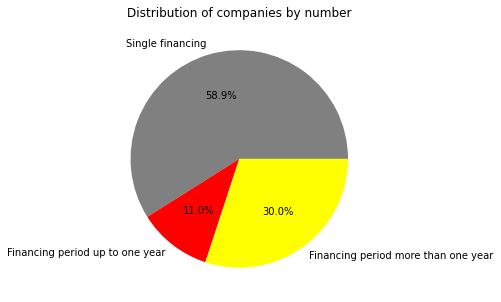

In [95]:
labels = ['Single financing', 'Financing period up to one year', 'Financing period more than one year']
counts = [single_funding_count, before_year_count, over_year_count]

plt.figure(figsize=(7, 5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['grey', 'red', 'yellow'])
plt.title('Distribution of companies by number')

plt.show()

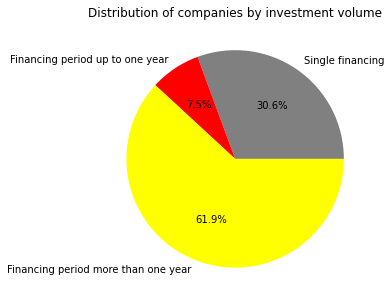

In [96]:
labels = ['Single financing', 'Financing period up to one year', 'Financing period more than one year']
counts = [single_funding_sum, before_year_sum, over_year_sum]

plt.figure(figsize=(7, 5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['grey', 'red', 'yellow'])
plt.title('Distribution of companies by investment volume')

plt.show()

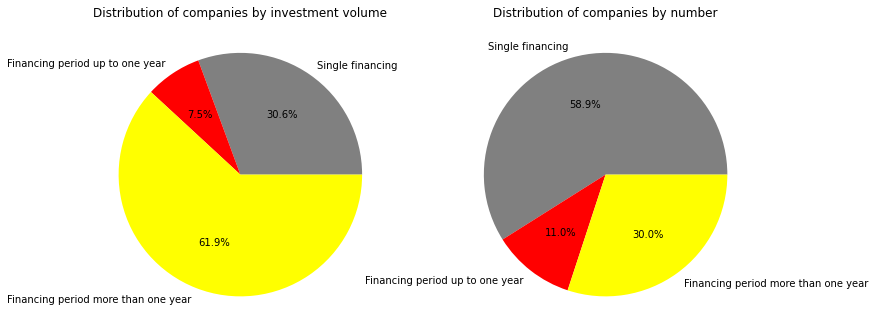

In [97]:
labels = ['Single financing', 'Financing period up to one year', 'Financing period more than one year']
counts1 = [single_funding_count, before_year_count, over_year_count]  # number of companies
counts2 = [single_funding_sum, before_year_sum, over_year_sum]  # investment volumes

# Create a figure and axes for two subgraphs
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 7))

# We are plotting a graph with investment volumes
ax1.pie(counts2, labels=labels, autopct='%1.1f%%', colors=['grey', 'red', 'yellow'])
ax1.set_title('Distribution of companies by investment volume')

# We plot a graph with the number of companies
ax2.pie(counts1, labels=labels, autopct='%1.1f%%', colors=['grey', 'red', 'yellow'])
ax2.set_title('Distribution of companies by number')

plt.show()

### 2.2 Identification of mid-market and niche market segments

Companies indicate their market segment in the "market" column. Calculate how often each segment appears in the dataset. Classify segments with more than 120 companies as mass-market, classify segments with 35 to 120 companies as mid-market, and classify segments with up to 35 companies as niche. Calculate how many segments fall into each category.

Plot a distribution chart of the number of companies in each segment and show the division into niche and mid-market segments.

In [98]:
market_counts = investments_df['market'].value_counts()

mass = market_counts[market_counts > 120]
medium = market_counts[(market_counts >= 35) & (market_counts <= 120)]
niche = market_counts[market_counts < 35]

mass_count = len(mass)
medium_count = len(medium)
niche_count = len(niche)

display(f"Number of mass segments: {mass_count}")
display(f"Number of medium segments: {medium_count}")
display(f"Number of niche segments: {niche_count}")

'Number of mass segments: 49'

'Number of medium segments: 57'

'Number of niche segments: 289'

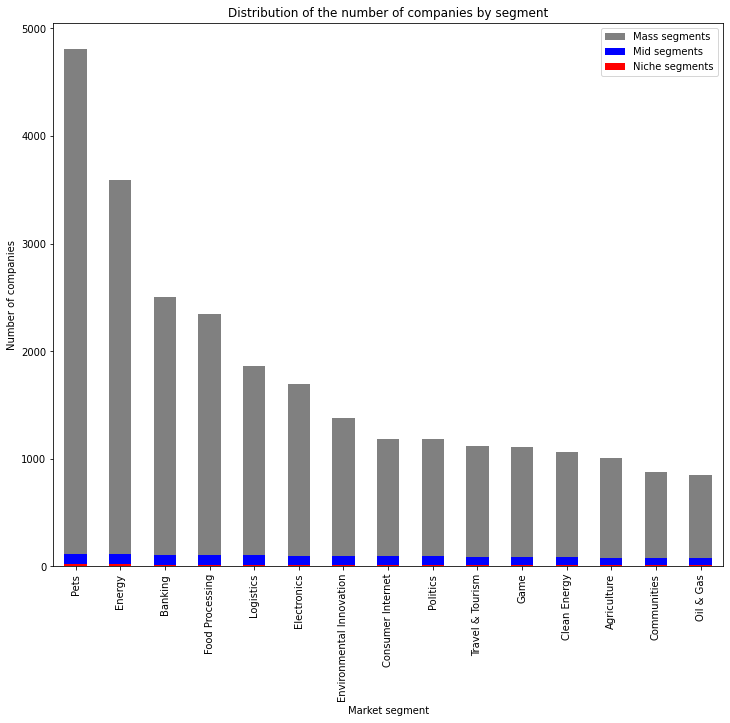

In [103]:
top_15_mass = mass.sort_values(ascending=False).head(15)
top_15_medium = medium.sort_values(ascending=False).head(15)
top_15_niche = niche.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 10))
top_15_mass.plot(kind='bar', color='gray', label='Mass segments')
top_15_medium.plot(kind='bar', color='blue', label='Mid segments')
top_15_niche.plot(kind='bar', color='red', label='Niche segments')
plt.title('Distribution of the number of companies by segment')
plt.xlabel('Market segment')
plt.ylabel('Number of companies')
plt.legend()

plt.show()

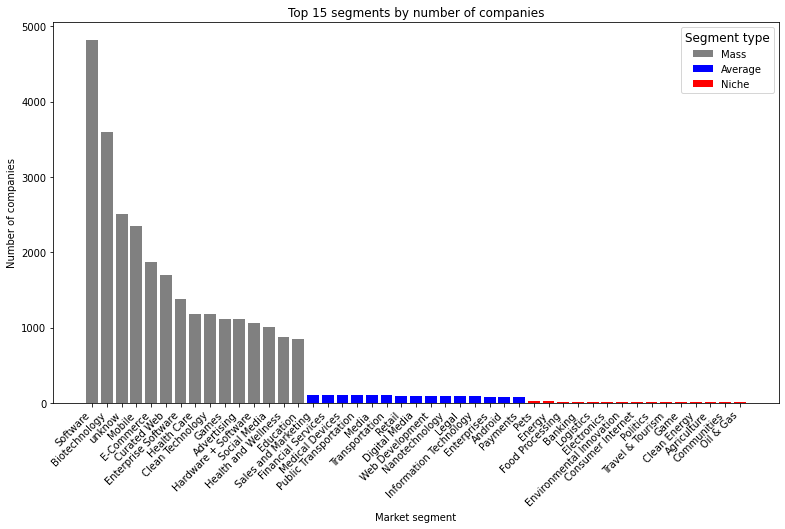

In [105]:
plot_data = []

for segment, count in top_15_mass.items():
    plot_data.append({'segment':segment, 'count':count, 'group':'Mass'})
for segment, count in top_15_medium.items():
    plot_data.append({'segment':segment, 'count':count, 'group':'Average'})
for segment, count in top_15_niche.items():
    plot_data.append({'segment':segment, 'count':count, 'group':'Niche'})

plot_df = pd.DataFrame(plot_data)

plot_df = plot_df.sort_values('count', ascending=False)

plt.figure(figsize=(13, 7))

# Draw bars with different colors by group
colors = {'Mass':'gray', 'Average':'blue', 'Niche':'red'}
bars = plt.bar(
    plot_df['segment'],
    plot_df['count'],
    color=[colors[g] for g in plot_df['group']]
)

plt.title('Top 15 segments by number of companies')
plt.xlabel('Market segment')
plt.ylabel('Number of companies')

plt.xticks(rotation=45, ha='right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
plt.legend(handles=legend_elements, title='Segment type', title_fontsize=12)

plt.show()

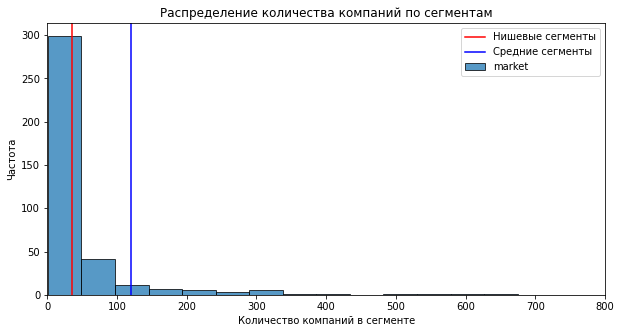

In [38]:
plt.figure(figsize=(10, 5))

market_counts.plot(
                kind='hist', # Тип графика - гистограмма
                bins=100, # Устанавливаем количество корзин 
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

plt.axvline(35, color='red', linestyle='-', label='Нишевые сегменты')
plt.axvline(120, color='blue', linestyle='-', label='Средние сегменты')
plt.xlim(0, 800)
plt.title('Распределение количества компаний по сегментам')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Частота')
plt.legend()

plt.show()

In the 'market' column, leave only the mass segments. For the remaining segments, replace the values ​​with placeholders: 'niche' for niche and 'mid' for mid-market.

Conduct further research with this replacement in mind. Individual segments within the mid-market and niche groups do not need to be considered; they are combined into two overall segments.


In [106]:
def market_segm(segment):
    if segment in mass:
        return segment
    elif segment in medium:
        return 'mid'
    else:
        return 'niche'
    
investments_df['market'] = investments_df['market'].apply(market_segm)

display(investments_df['market'])

0        Education
1           unknow
2              mid
3        Education
4        Education
           ...    
49433       unknow
49434        niche
49435       unknow
49436       unknow
49437     Startups
Name: market, Length: 40907, dtype: object

## Step 3. Working with outliers and analysis

### 3.1. We analyze and mark outliers in each segment

The client is interested in the typical amount of funding provided to companies for the period in question.

Using the preprocessed `funding_total_usd` column, graphically estimate what amount of total funding for a single company would be typical and what would be outliers. Specify the range within which typical values lie.

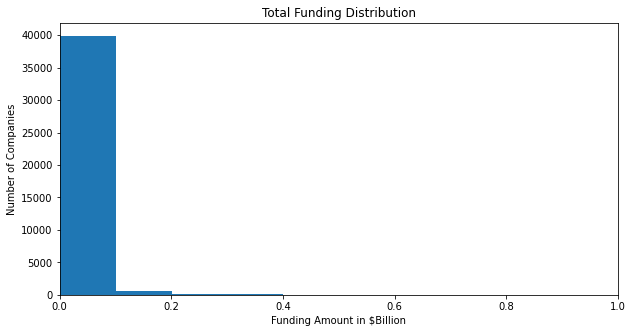

In [107]:
plt.figure(figsize=(10, 5))

(investments_df['funding_total_usd']/1000000000).plot(
                kind='hist', 
                bins=300,  
)

plt.title('Total Funding Distribution')
plt.xlabel('Funding Amount in $Billion')
plt.ylabel('Number of Companies')
plt.xlim(0, 1)
plt.show()

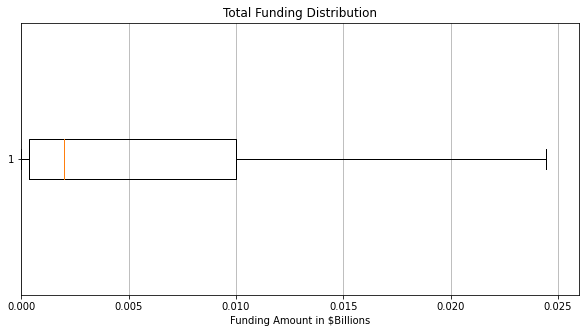

In [108]:
plt.figure(figsize=(10, 5))

plt.boxplot(investments_df['funding_total_usd']/1000000000, vert=False, showfliers=False)

plt.title('Total Funding Distribution')
plt.xlabel('Funding Amount in $Billions')
plt.xlim(0, 0.026)
plt.grid(axis='x')

plt.show()

Typical funding amounts for companies range from 0 $ to 24.5 $ million.

Identify companies with abnormal amounts of total funding using the IQR method separately for each segment. Remember, all niche segments should be grouped together, and mid-sized segments should be grouped together.

Identify market segments with the highest share of companies that received abnormal funding and derive the top segments.

In [109]:
outlier_stats = []

investments_df['outlier'] = False

for market_group, group in investments_df.groupby('market'):
    total_companies = len(group)
    if total_companies == 0:
        continue
    funding = group['funding_total_usd']
    Q1 = funding.quantile(0.25)
    Q3 = funding.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = 0
    upper_bound = Q3 + 1.5 * IQR
    outlier = (funding < lower_bound) | (funding > upper_bound) # abnormal values
    outlier_count = outlier.sum()
    outlier_ratio = outlier_count / total_companies
    outlier_stats.append({'segment': market_group,
                          'total_companies': total_companies,
                          'outlier_companies': outlier_count,
                          'outlier_ratio': outlier_ratio})
    investments_df.loc[group.index, 'outlier'] = outlier
    
outlier_df = pd.DataFrame(outlier_stats)

outlier_df_sorted = outlier_df.sort_values('outlier_ratio', ascending=False)

# We display the top 15 by the proportion of abnormal values
display(outlier_df_sorted[['segment', 'outlier_ratio', 'total_companies', 'outlier_companies']].head(15))


,segment,outlier_ratio,total_companies,outlier_companies
34,Real Estate,0.172043,279,48
14,Entertainment,0.166667,150,25
8,Consulting,0.166189,349,58
36,Search,0.164948,291,48
7,Cloud Computing,0.164474,152,25
32,Photography,0.161765,204,33
35,SaaS,0.161765,272,44
44,Technology,0.159664,238,38
46,Video,0.159574,188,30
49,niche,0.159036,830,132


### 3.2 We define the boundaries of the period under consideration and discard anomalies

Check the dataset to see if you've been provided with complete data for 2014. Then, exclude from the dataset the companies you previously identified as having received anomalous funding.

Once you've excluded the anomalous records, use the `mid_funding_at` and `funding_rounds` columns to retain data only for certain companies. These companies must have received funding in years with 50 or more funding rounds.

In [110]:
# Filter data for 2014
df_2014_first = investments_df[investments_df['first_funding_at'].dt.year == 2014]
df_2014_last = investments_df[investments_df['last_funding_at'].dt.year == 2014]

# Count by month for first_funding_at
monthly_count_first = df_2014_first['first_funding_at'].dt.month.value_counts().sort_index()
total_first = monthly_count_first.sum() # Total number of data for 2014
print(f"Number of first_funding_at records by month for 2014: \n{monthly_count_first}")
print(f"Total number of first_funding_at records for 2014: {total_first}\n")

# Calculate by month for last_funding_at
monthly_count_last = df_2014_last['last_funding_at'].dt.month.value_counts().sort_index()
total_last = monthly_count_last.sum() # Total number of data for 2014
print(f"Number of last_funding_at records by month for 2014: \n{monthly_count_last}")
print(f"Total number of last_funding_at records for 2014: {total_last}")



Number of first_funding_at records by month for 2014: 
1     810
2     635
3     661
4     593
5     549
6     669
7     671
8     525
9     538
10    492
11    311
12     23
Name: first_funding_at, dtype: int64
Total number of first_funding_at records for 2014: 6477

Number of last_funding_at records by month for 2014: 
1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1135
10    1139
11     732
12      52
Name: last_funding_at, dtype: int64
Total number of last_funding_at records for 2014: 11915


In [111]:
display(returns_df.loc[2014])

seed                     530.75
venture                 7272.01
equity_crowdfunding        1.15
undisclosed              105.72
convertible_note           7.87
debt_financing          1017.75
angel                    293.98
grant                      0.00
private_equity           384.01
post_ipo_equity          262.70
post_ipo_debt             37.20
secondary_market           1.03
product_crowdfunding       0.72
Name: 2014, dtype: float64

The data filtered by funding in the investments_df dataset (first_funding_at and last_funding_at) for 2014 is present in significant volume.
Data in the returns_df dataset for 2014 is present in all columns, indicating sufficient data.

In [112]:
investments_df_clean = investments_df[investments_df['outlier'] == False].copy()

display(f"Before cleanup: {len(investments_df)}")
display(f"After cleanup: {len(investments_df_clean)}")

'Before cleanup: 40907'

'After cleanup: 35663'

In [113]:
investments_df_clean['mid_funding_at'] = pd.to_datetime(investments_df_clean['mid_funding_at'])

investments_df_clean['year'] = investments_df_clean['mid_funding_at'].dt.year

year_rounds = investments_df_clean.groupby('year')['funding_rounds'].sum()

year_rounds_filt = year_rounds[year_rounds >= 50]

active_years = year_rounds_filt.index.tolist()

investments_df_clean = investments_df_clean[investments_df_clean['year'].isin(active_years)]

print(active_years)

[2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


### 3.3. Analysis of financing types by volume and popularity

Let's plot a graph showing which funding types attracted the most funds overall. We'll use the values ​​in the columns 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', and 'product_crowdfunding'.

We'll also plot a graph showing the popularity of different funding types—which types of funding are most frequently used by companies, meaning they appear the most frequently in the dataset.

We'll compare the graphs and highlight frequently used funding types that are characterized by small volumes, and, conversely, those that are rare but characterized by significant amounts of funds provided.

In [114]:
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

total_funding = investments_df_clean[funding_types].sum().sort_values(ascending = False)

popularity = investments_df_clean[funding_types].astype(bool).sum()
print(popularity)

seed                    13375
venture                 18820
equity_crowdfunding       515
undisclosed               813
convertible_note          521
debt_financing           3265
angel                    2937
grant                    1003
private_equity            634
post_ipo_equity           164
post_ipo_debt              27
secondary_market            7
product_crowdfunding      204
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

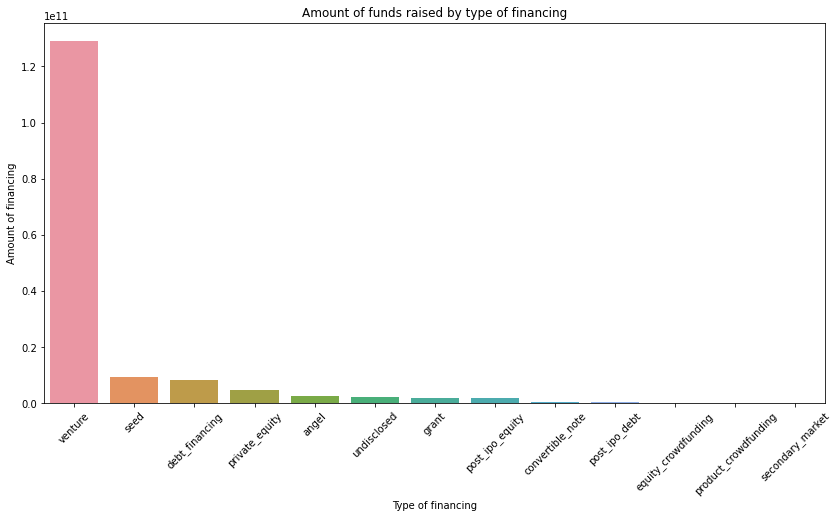

In [115]:
plt.figure(figsize=(14, 7))
sns.barplot(
    x=total_funding.index,
    y=total_funding
)
plt.xticks(rotation=45)

plt.title('Amount of funds raised by type of financing')
plt.xlabel('Type of financing')
plt.ylabel('Amount of financing')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

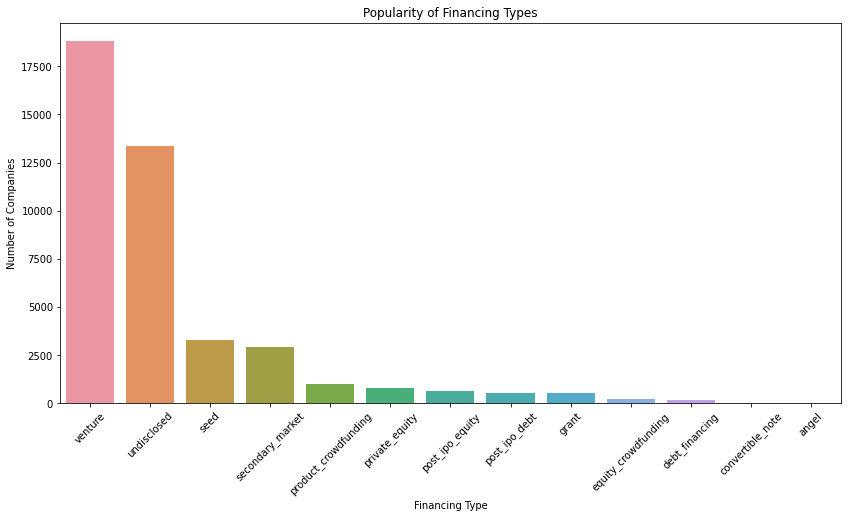

In [116]:
plt.figure(figsize=(14, 7))
sns.barplot(
    x=popularity.index.sort_values(ascending=False),
    y=popularity.sort_values(ascending=False)
)
plt.xticks(rotation=45)

plt.title('Popularity of Financing Types')
plt.xlabel('Financing Type')
plt.ylabel('Number of Companies')

plt.show

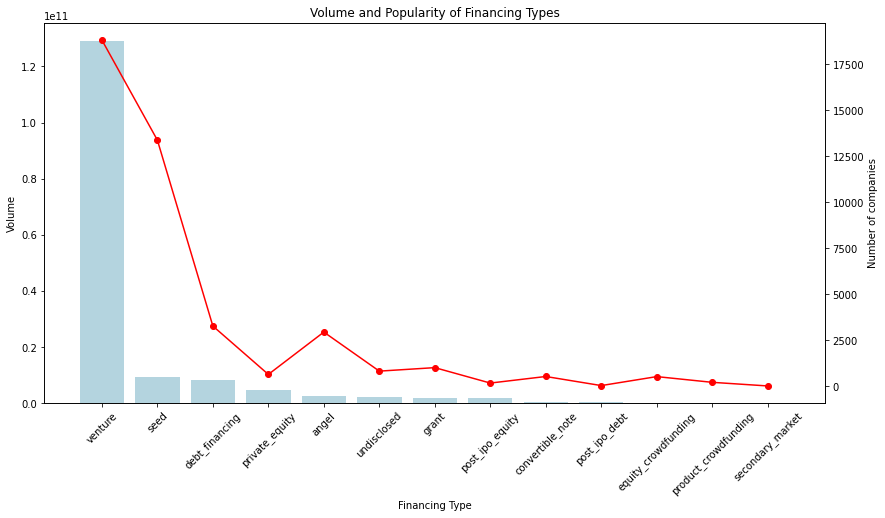

In [117]:
plt.figure(figsize=(14, 7))

sns.barplot(
    x=total_funding.index,
    y=total_funding,
    color = 'lightblue',
)
plt.xticks(rotation=45)

plt.title('Volume and Popularity of Financing Types')
plt.xlabel('Financing Type')
plt.ylabel('Volume')

# Building a popularity line
ax2 = plt.twinx()
ax2.plot(total_funding.index, popularity.loc[total_funding.index],
         color='red', marker='o')
ax2.set_ylabel('Number of companies')

plt.show()

Seed is a frequently used type of financing, which is characterized by small volumes, while venture is the most common type of financing with the largest volumes.

We will plot a graph of total repayment volumes from different types of financing for the entire period based on an additional dataset.

In [118]:
# We sum up the returns for each type for the entire period
total_returns = returns_df[funding_types].sum()

# Convert to DataFrame
returns_summary = total_returns.to_frame(name = 'total_return_usd').reset_index()
returns_summary.columns = ['funding_type', 'total_return_usd']

returns_summary = returns_summary.sort_values('total_return_usd', ascending=False)
print(returns_summary)

            funding_type  total_return_usd
1                venture          40578.62
5         debt_financing           4734.85
8         private_equity           3587.33
0                   seed           2382.24
6                  angel           1509.23
9        post_ipo_equity           1104.96
3            undisclosed            730.88
10         post_ipo_debt             91.03
4       convertible_note             34.79
11      secondary_market              5.20
2    equity_crowdfunding              3.83
12  product_crowdfunding              1.86
7                  grant              0.00


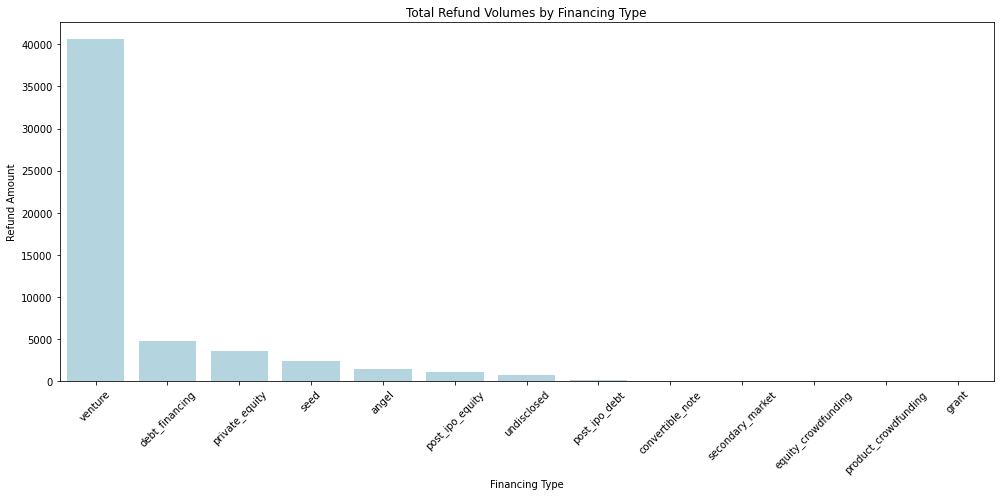

In [119]:
plt.figure(figsize=(14, 7))
sns.barplot(data=returns_summary, x='funding_type', y='total_return_usd', color = 'lightblue')
plt.title('Total Refund Volumes by Financing Type')
plt.ylabel('Refund Amount')
plt.xlabel('Financing Type')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Step 4. Dynamics analysis

### 4.1 Dynamics of funding provision by year

Using the `funding_total_usd` and `funding_rounds` columns, we'll calculate the average size of a single funding round for each company.

Based on the resulting table, we'll create graphs showing:
* the typical amount of funding startups received in a single funding round;

* the total number of rounds for each year, i.e., how active the market was with investments (the more rounds, the higher the activity).

Based on the data obtained, we'll answer the following questions:
* In which year was the typical amount of funds raised in a single round the highest?

* What trend was observed in 2014 in terms of the number of rounds and the funds allocated in each round?

In [120]:
investments_df_clean['avg_round'] = np.where(
    (investments_df_clean['funding_rounds'] > 0) & (investments_df_clean['funding_total_usd'].notna()),
    investments_df_clean['funding_total_usd'] / investments_df_clean['funding_rounds'],
    np.nan)

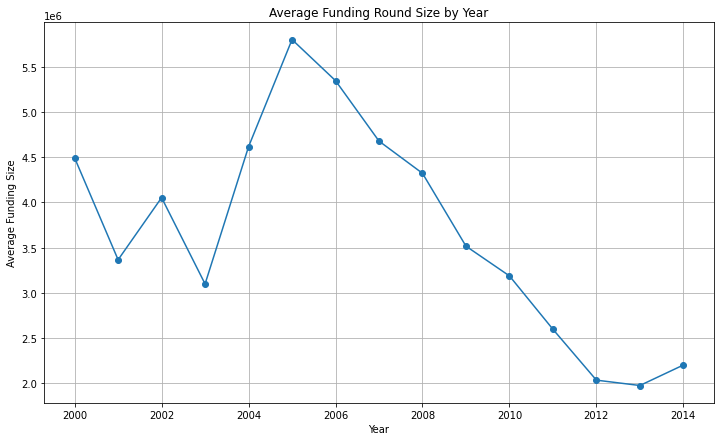

In [121]:
# We calculate the average size of 1 round by year

yearly_avg = investments_df_clean.groupby('year')['avg_round'].mean()

# We're plotting a chart of the typical amount of funding startups receive in a single funding round.

plt.figure(figsize=(12, 7))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title('Average Funding Round Size by Year')
plt.xlabel('Year')
plt.ylabel('Average Funding Size')
plt.grid()

plt.show()

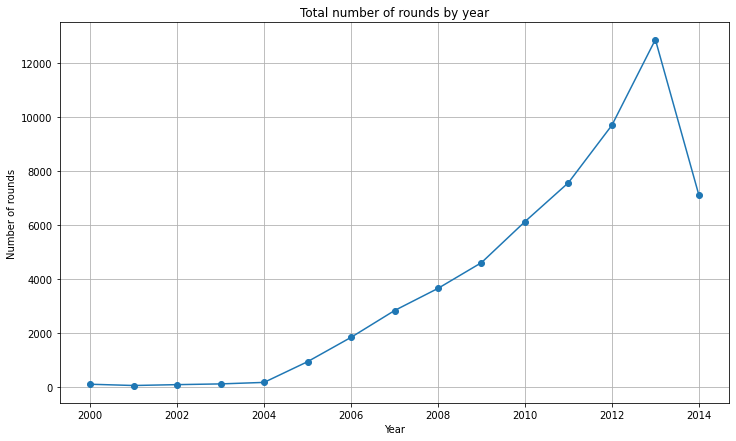

In [122]:
# We count the number of rounds by year

yearly_rounds = investments_df_clean.groupby('year')['funding_rounds'].sum()

# We plot a graph of the total number of rounds by year

plt.figure(figsize=(12, 7))
plt.plot(yearly_rounds.index, yearly_rounds.values, marker='o')
plt.title('Total number of rounds by year')
plt.xlabel('Year')
plt.ylabel('Number of rounds')
plt.grid()

plt.show()

The typical amount of funds raised in a single round peaked in 2005.
2014 saw the lowest funding volume of all years studied, as well as a decrease in the number of funding rounds compared to 2011-2013.

### 4.2 Dynamics of the size of total financing by mass market segments for segments growing in 2014

Let's create a summary table showing the total funding amount (funding_total_usd) by year and market segment. We'll select only those segments that showed an increase in total funding in 2014 compared to 2013.

The graph will show how the total funding amount changed in each of the selected segments by year for which we have sufficient data. We'll consider only mass-market segments, excluding mid-market and niche segments.

Based on the graph, we'll draw conclusions about which segments are showing the fastest and most consistent growth.

In [123]:
# Building a pivot table

funding_sum = investments_df_clean.pivot_table(
    index='year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum'
)

funding_sum

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Software,Sports,Startups,Technology,Travel,Video,Web Hosting,mid,niche,unknow
year,,,,,,,,,,,,,,,,,,,,,
2000.0,14470000.0,14822803.0,NaN,NaN,NaN,NaN,NaN,11500000.0,4500000.0,1000000.0,...,3.173264e+07,NaN,NaN,NaN,50230.0,NaN,95343090.0,8.244039e+07,14600000.0,1839560.0
2001.0,8778321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305000.0,...,2.781135e+07,NaN,NaN,22160000.0,NaN,NaN,15000000.0,9.441026e+06,24020000.0,10160345.0
2002.0,24500000.0,7500000.0,NaN,NaN,NaN,NaN,3.439044e+07,NaN,NaN,4650000.0,...,1.010264e+08,200000.0,NaN,11000000.0,NaN,NaN,NaN,1.888580e+07,NaN,242132.0
2003.0,10500000.0,3840000.0,NaN,4530000.0,NaN,8.553118e+07,5.035294e+07,NaN,NaN,2550000.0,...,6.608604e+07,NaN,NaN,NaN,NaN,5000000.0,NaN,4.323840e+07,NaN,4155202.0
2004.0,6000000.0,3000000.0,NaN,NaN,NaN,9.718486e+07,5.042795e+07,NaN,NaN,27050000.0,...,1.408238e+08,NaN,NaN,1750000.0,10230000.0,14704000.0,27000000.0,5.443816e+07,NaN,10847977.0
2005.0,127196022.0,79014044.0,NaN,22500000.0,NaN,4.800636e+08,1.942000e+07,NaN,44862000.0,53450000.0,...,9.930766e+08,1882200.0,NaN,50728425.0,27830000.0,6470551.0,483332632.0,2.144075e+08,NaN,28384331.0
2006.0,299299458.0,139701311.0,1310600.0,12660000.0,NaN,9.035005e+08,1.314739e+08,9951809.0,23965548.0,164673698.0,...,1.646869e+09,7000000.0,NaN,22791000.0,11700000.0,35171772.0,649959267.0,3.475226e+08,11180000.0,46049840.0
2007.0,556704331.0,98829000.0,NaN,37712601.0,7780000.0,1.704078e+09,7.497112e+08,20354343.0,70346345.0,314704515.0,...,1.686116e+09,16401580.0,NaN,180190209.0,13950000.0,85150644.0,361121449.0,5.035429e+08,44494637.0,35532468.0
2008.0,622673464.0,208077840.0,4300000.0,59478635.0,2452515.0,1.716033e+09,3.165808e+09,44375000.0,19061080.0,336500027.0,...,1.365006e+09,9554790.0,5010387.0,277726238.0,54905631.0,37865177.0,781623731.0,5.503748e+08,22279331.0,45345010.0


In [124]:
# We take only 2013 and 2014

funding_data_13_14 = funding_sum.loc[[2013, 2014]]


# We leave the segments that showed an increase in the size of total financing in 2014 compared to 2013

growth_2014 = (funding_data_13_14.loc[2014] / funding_data_13_14.loc[2013]) - 1

growing_markets = growth_2014[growth_2014 > 0].index.tolist()

growing_markets

['Apps',
 'Big Data',
 'Design',
 'Internet',
 'Manufacturing',
 'Medical',
 'Real Estate',
 'SaaS',
 'Startups',
 'Technology',
 'mid',
 'niche',
 'unknow']

In [125]:
# We leave only mass segments

mass_markets = [
    market for market in growing_markets
    if market not in ['mid', 'niche']]
mass_markets

['Apps',
 'Big Data',
 'Design',
 'Internet',
 'Manufacturing',
 'Medical',
 'Real Estate',
 'SaaS',
 'Startups',
 'Technology',
 'unknow']

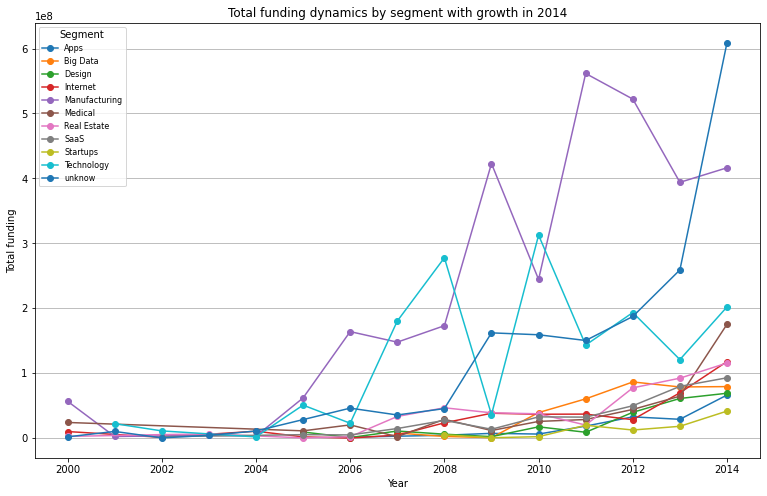

In [126]:
plt.figure(figsize=(13, 8))

for market in mass_markets:
    series = funding_sum[market].dropna()
    if len(series) > 1:
        plt.plot(series, marker='o', label=market)

plt.title('Total funding dynamics by segment with growth in 2014')
plt.xlabel('Year')
plt.ylabel('Total funding')
plt.legend(title='Segment', fontsize=8)
plt.grid(axis='y')

plt.show()

Segments like Apps show the fastest and most consistent funding growth. Medical, SaaS, and Real Estate show moderate to insignificant growth in overall funding. However, segments like Manufacturing and Technology tend to experience spikes and declines in funding.

### 4.3 Annual dynamics of the share of returned funds by type of financing

The client wants to know what portion of the invested or issued funds is returned to investors or financiers over time. Our goal is to calculate standardized return values ​​for each year and each type of financing: that is, what proportion of funds provided are returned. Any excessively large outliers, or outliers, should be replaced with missing values.

In [127]:
# One year with average funding size

investments_df_clean['mid_funding_year'] = investments_df_clean['mid_funding_at']
investments_df_clean['mid_funding_year'] = pd.to_datetime(investments_df_clean['mid_funding_year']).dt.year

funding_pivot = investments_df_clean.pivot_table(values = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                    'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'],
                    index='mid_funding_year',
                    aggfunc='sum')

returns_ratio = returns_df / (funding_pivot + 1e-60)

returns_ratio

,angel,convertible_note,debt_financing,equity_crowdfunding,grant,post_ipo_debt,post_ipo_equity,private_equity,product_crowdfunding,secondary_market,seed,undisclosed,venture
year,,,,,,,,,,,,,
2000,2.669564e-07,0.000000e+00,6.185714e-07,0.000000e+00,0.0,0.000000e+00,2.710694e-07,0.000000e+00,0.000000e+00,2.591054e-08,9.964712e-07,6.970424e-07,1.689219e-07
2001,1.180000e-06,6.666667e-09,7.702578e-07,0.000000e+00,0.0,0.000000e+00,4.600000e+59,0.000000e+00,0.000000e+00,4.600000e+59,1.079592e-06,5.874833e-07,1.079905e-07
2002,1.136667e-06,2.000000e+58,2.233882e-07,0.000000e+00,0.0,0.000000e+00,1.133333e-06,2.013333e-07,0.000000e+00,6.000000e+58,6.297066e-07,6.088783e-07,6.822818e-07
2003,6.057203e-07,1.000000e+58,1.038095e-06,0.000000e+00,0.0,0.000000e+00,2.110000e+60,1.620000e+60,0.000000e+00,8.000000e+58,5.052762e-07,9.143969e-07,6.282600e-07
2004,8.335043e-07,1.000000e+58,4.396978e-07,0.000000e+00,0.0,0.000000e+00,3.380000e+60,2.190000e+60,0.000000e+00,5.500000e+59,5.484755e-07,5.275593e-07,8.370091e-07
2005,5.098940e-07,2.000000e+58,3.449644e-07,0.000000e+00,0.0,0.000000e+00,7.318565e-07,4.800000e-07,0.000000e+00,5.000000e+58,6.746954e-07,1.071992e-06,5.465859e-07
2006,6.748530e-07,1.663181e-07,8.037720e-07,2.036317e-07,0.0,0.000000e+00,2.058000e+61,9.354530e-07,0.000000e+00,1.200000e+59,9.253718e-07,7.594382e-07,3.436776e-07
2007,8.178375e-07,2.280972e-07,6.024881e-07,1.000000e+58,0.0,0.000000e+00,2.030000e-06,5.790563e-07,0.000000e+00,5.700000e+59,3.661533e-07,5.049708e-07,2.972428e-07
2008,4.124756e-07,5.978832e-08,9.274838e-07,3.000000e+58,0.0,0.000000e+00,2.341111e-06,6.799254e-07,0.000000e+00,4.700000e+59,2.970831e-07,3.420604e-07,1.908726e-07


Let's plot a graph displaying the normalized return on assets values ​​for the following financing types: venture, debt financing, private equity, seed, and angel.

We'll determine which financing types are experiencing the most consistent growth in this indicator.

In [128]:
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

selected_ratio = returns_ratio[selected_types]

# We normalize the values

normalized_ratios = (selected_ratio - selected_ratio.min()) / (selected_ratio.max() - selected_ratio.min())

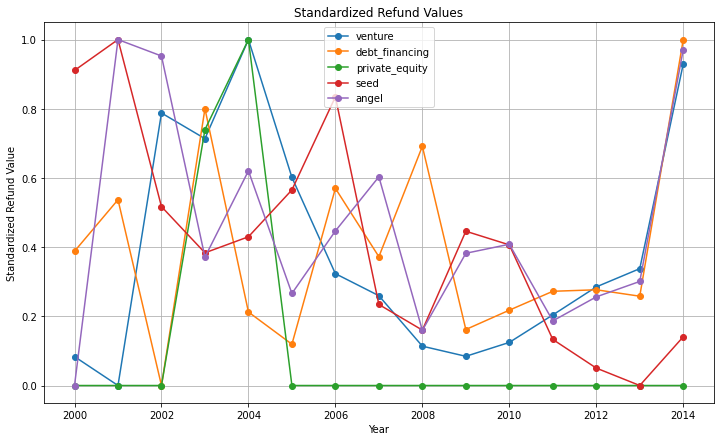

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,0.083580,0.388062,0.000000,0.910784,0.000000
2001,0.000000,0.537014,0.000000,1.000000,1.000000
2002,0.787759,0.000000,0.000000,0.517125,0.952540
2003,0.713657,0.800025,0.739726,0.383571,0.371027
2004,1.000000,0.212411,1.000000,0.429938,0.620505
2005,0.601624,0.119385,0.000000,0.565413,0.266075
2006,0.323294,0.569925,0.000000,0.834471,0.446744
2007,0.259599,0.372268,0.000000,0.234246,0.603346
2008,0.113690,0.691407,0.000000,0.160111,0.159378


In [129]:
plt.figure(figsize=(12, 7))

for column in normalized_ratios.columns:
    plt.plot(normalized_ratios.index, normalized_ratios[column], label=column, marker='o')

plt.title('Standardized Refund Values')
plt.xlabel('Year')
plt.ylabel('Standardized Refund Value')
plt.legend()
plt.grid(True)
plt.show()

display(normalized_ratios.style.background_gradient(cmap='viridis'))


Financing types such as venture (since 2009), angel (since 2011), and debt_financing (since 2010) have seen a steady increase in cash recovery rates.
Private_equity financing has seen virtually no cash recovery.
Seed financing is characterized by volatility in returns.


## Step 5. Final conclusion and recommendations

**Executed Steps**

**Step 1. Data Familiarization and Preprocessing**
- Column names were standardized.

- The 'funding_total_usd' column was cleared of thousands separators and converted to a numeric type.

- Dates ('mid_funding_at', 'first_funding_at', 'last_funding_at') were converted to datetime.

- In 'returns_df', the 'year' column was set as an index.

- Text data was processed: gaps were filled with placeholders ('unknown').
- Complete duplicates and rows without funding data were removed.
- Gaps in 'mid_funding_at' were filled with the midpoint of the interval between 'first_funding_at' and 'last_funding_at'.
- Data completeness and the percentage of discarded records were assessed (almost 25%).


**Step 2. Feature Engineering**
- Companies are divided into 3 groups based on funding duration:

- Single funding;

- Term ≤1 year;

- Term >1 year.

- Market segments are classified as mass (more than 120 companies), mid-market (35–120), and niche (less than 35).
- Niche and mid-market segments are replaced with placeholders.


**Step 3. Outlier Management and Analysis**
- For each segment (including the combined 'niche' and 'mid' segments), companies with anomalous funding volumes were identified using the IQR method.
- Segments with the highest proportion of anomalies were identified.
- Data completeness for 2014 was verified; anomalous records were excluded.
- Only companies with ≥50 funding rounds per year were retained.
- Volume and frequency were compared: types with low volume/high frequency were identified, and vice versa.


**Step 4. Dynamics Analysis**
- The average round size was calculated for each company: `funding_total_usd / funding_rounds`.
- A summary table of funding by year was created for mass-market segments; segments with growth in 2014 compared to 2013 were selected.
- A graph of funding dynamics for the selected segments was created.
- Normalized return ratios were calculated by year and type of funding.

**Conclusions**

1. **Market structure by funding duration**
- Most companies receive one-time funding or raise funds for periods of less than 1 year.

2. **Market segmentation**
- Niche segments dominate in terms of number of companies and investment volume.
- Niche and mid-market segments are combined for statistical consistency; their individual dynamics are not analyzed.

3. **Anomalies and Risks**

Typical funding volumes for companies range from $0 to $24.5 million.
- A high proportion of companies with abnormally high funding levels were identified in certain segments.
These include:
- Real Estate (17.2%)
- Entertainment (16.7%)
- Consulting (16.6%)
- Search (16.5%)
- Cloud Computing (16.4%)

4. **Funding Types: Volume and Popularity**
- Venture leads in total funding volumes and popularity.
- Undisclosed funding is common, but characterized by small funding levels.
- Returns are most significant for Venture.


5. **Year-over-Year Dynamics**
- The highest average round size occurred in **2013**
- In **2014** compared to 2013: 
- The number of rounds decreased by 46%; 
- The average funding size per round in 2014 was $2.2 million.

6. **Segment Growth**
- Among the mass segments, Apps showed the fastest funding growth in 2014.
- Medical, SaaS, and Real Estate showed moderate to insignificant growth in total funding.


7. **Return Ratio** 
- In financing types such as venture (since 2009), angel (since 2011), and debt_financing (since 2010), there has been a steady increase in the return on investment.

**Conclusion**

Based on the analysis, we can conclude that investing is worthwhile in the Apps segment (with the fastest funding growth) and Real Estate (characterized by the share of companies with high funding).

Venture - this type of financing will be the most appropriate.